# Proyecto Final
## Análisis Estadístico de Datos COVID-19 en Python

### Materia:
#####Probabilidad y Estadística

### Grupo:
#####2YY

### Periodo:
#####Enero-Junio

### Fecha:
#####25/05/2026

### Integrantes:
#####Juan Antonio Alvarado Barron
#####Angel Rios

### Docente:
#####Jose Gabriel Rodriguez Rivas

###Estadistica descriptiva

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd

ruta = '/content/drive/MyDrive/covid2020-2021-codificado.csv'

df = pd.read_csv(ruta, low_memory=False)

print(df.head())

   SECTOR       SEXO       ENTIDAD_NAC TIPO_PACIENTE FECHA_INGRESO  \
0  Issste   Femenino   San Luis Potosí   Ambulatorio    2020-12-06   
1  Issste  Masculino   San Luis Potosí   Ambulatorio    2020-02-20   
2     Ssa   Femenino           Jalisco   Ambulatorio    2020-04-22   
3     Ssa  Masculino         Chihuahua   Ambulatorio    2020-07-28   
4     Ssa  Masculino  Ciudad De México   Ambulatorio    2020-08-18   

    FECHA_DEF   INTUBADO NEUMONIA  EDAD   EMBARAZO  ... DIABETES EPOC ASMA  \
0  9999-99-99  No aplica       No    55         No  ...       Si   No   No   
1  9999-99-99  No aplica       No    59  No aplica  ...       No   No   No   
2  9999-99-99  No aplica       No    42         No  ...       No   No   Si   
3  9999-99-99  No aplica       No    35  No aplica  ...       No   No   No   
4  9999-99-99  No aplica       No    51  No aplica  ...       No   No   No   

  HIPERTENSION CARDIOVASCULAR OBESIDAD RENAL_CRONICA TABAQUISMO  \
0           No             No       No     

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set(style='whitegrid')

In [22]:
print(df.columns)

Index(['SECTOR', 'SEXO', 'ENTIDAD_NAC', 'TIPO_PACIENTE', 'FECHA_INGRESO',
       'FECHA_DEF', 'INTUBADO', 'NEUMONIA', 'EDAD', 'EMBARAZO', 'INDIGENA',
       'DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR',
       'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO', 'RESULTADO_ANTIGENO', 'UCI'],
      dtype='object')


In [23]:
resultado = df['RESULTADO_ANTIGENO'].value_counts()

print(resultado)

RESULTADO_ANTIGENO
Negativo     5853547
Pendiente    5005939
Positivo     1774708
Name: count, dtype: int64


In [24]:
pacientes = df['TIPO_PACIENTE'].value_counts()

print(pacientes)

TIPO_PACIENTE
Ambulatorio      11543303
Hospitalizado     1090891
Name: count, dtype: int64


In [25]:
embarazadas = (df['EMBARAZO'] == 1).sum()

print('Pacientes embarazadas:', embarazadas)

Pacientes embarazadas: 0


In [26]:
indigenas = (df['INDIGENA'] == 1).sum()

print('Pacientes indígenas:', indigenas)

Pacientes indígenas: 0


###Visualizaciones

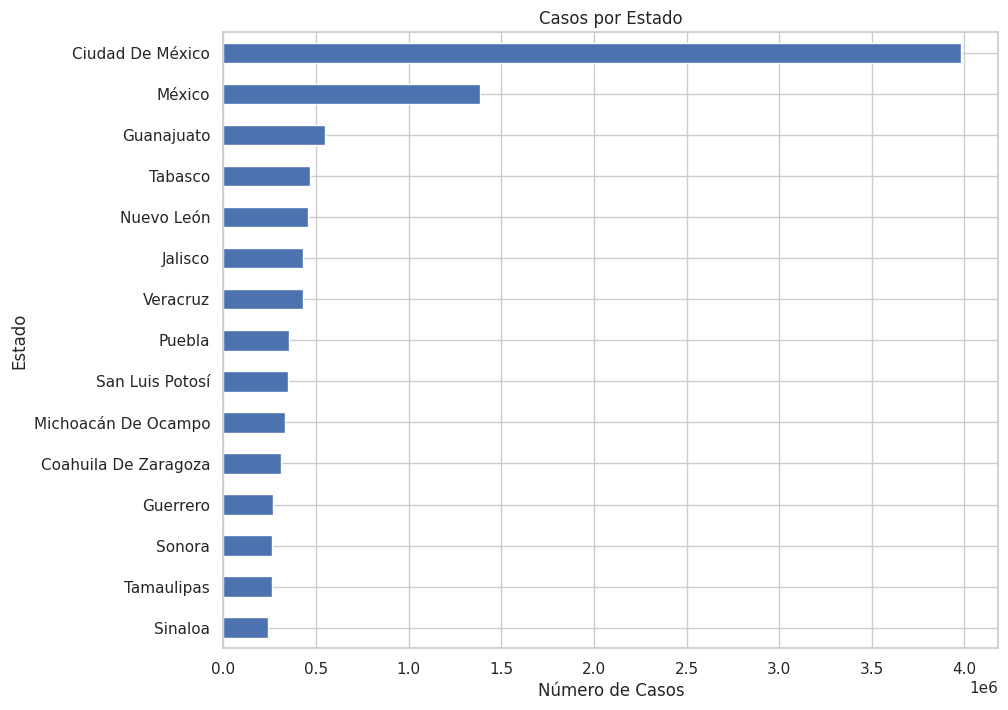

In [27]:
estado = df['ENTIDAD_NAC'].value_counts().head(15)

plt.figure(figsize=(10,8))

estado.sort_values().plot(kind='barh')

plt.title('Casos por Estado')
plt.xlabel('Número de Casos')
plt.ylabel('Estado')

plt.show()

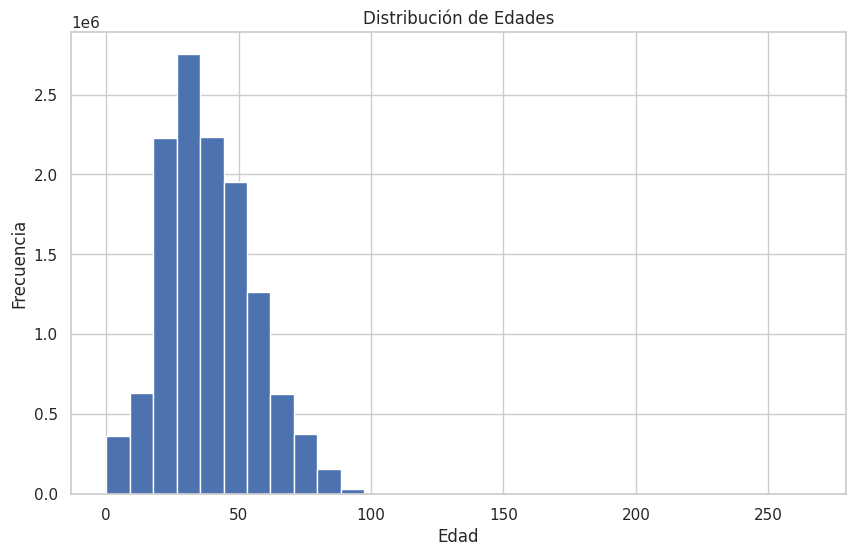

In [28]:
plt.figure(figsize=(10,6))

plt.hist(df['EDAD'].dropna(), bins=30)

plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

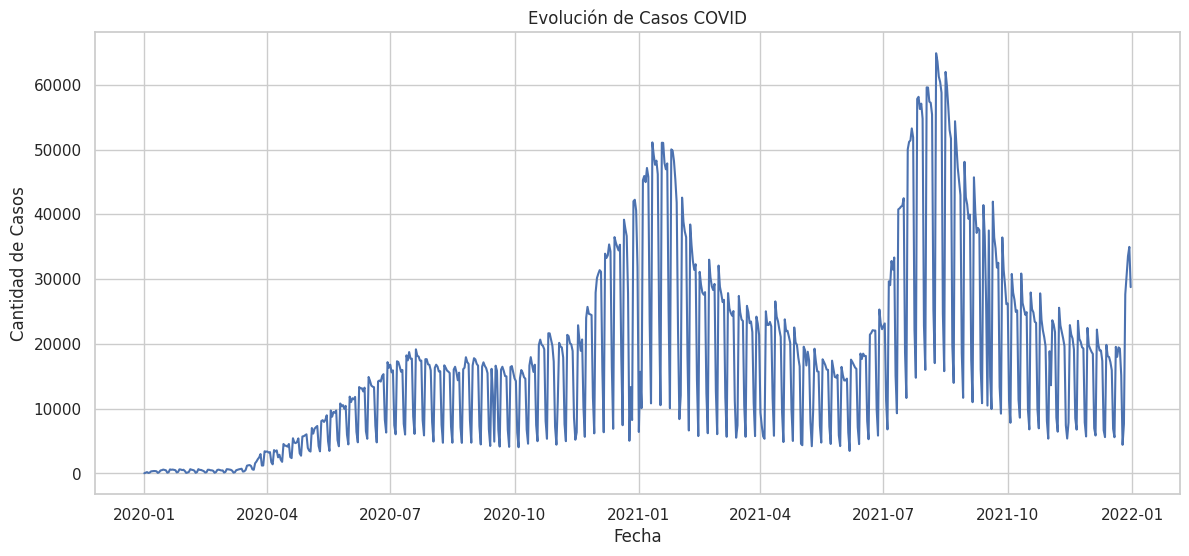

In [29]:
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'])

casos_fecha = df.groupby('FECHA_INGRESO').size()

plt.figure(figsize=(14,6))

plt.plot(casos_fecha)

plt.title('Evolución de Casos COVID')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Casos')

plt.show()

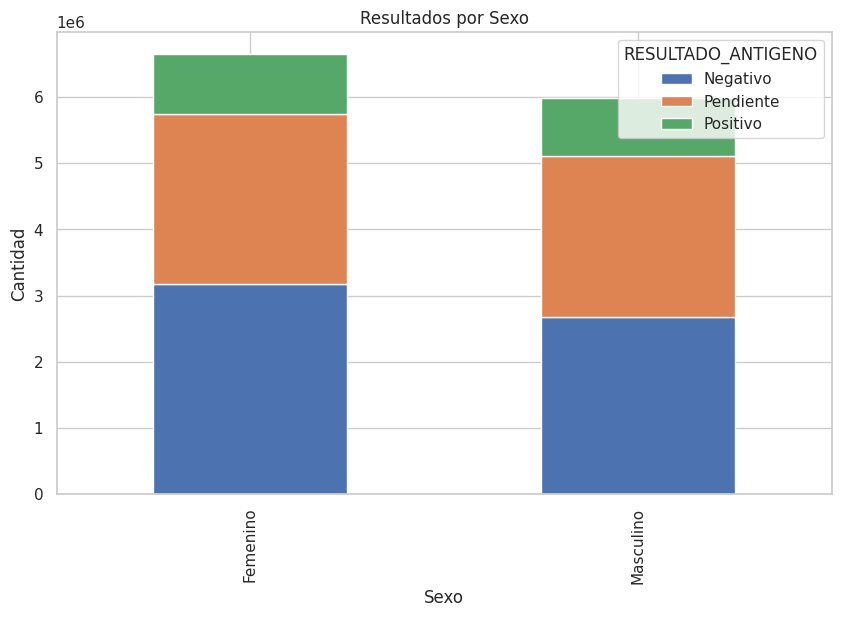

In [30]:
tabla = pd.crosstab(df['SEXO'], df['RESULTADO_ANTIGENO'])

tabla.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Resultados por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')

plt.show()

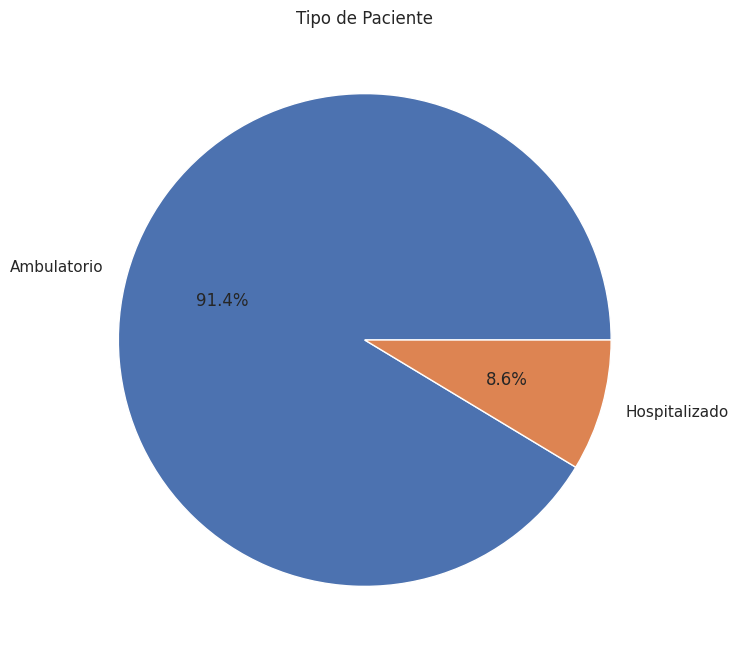

In [31]:
tipo = df['TIPO_PACIENTE'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(tipo, labels=tipo.index, autopct='%1.1f%%')

plt.title('Tipo de Paciente')

plt.show()

In [32]:
print("DIABETES")
print(df['DIABETES'].value_counts())

print("\nHIPERTENSION")
print(df['HIPERTENSION'].value_counts())

print("\nOBESIDAD")
print(df['OBESIDAD'].value_counts())

print("\nASMA")
print(df['ASMA'].value_counts())

print("\nEPOC")
print(df['EPOC'].value_counts())

print("\nCARDIOVASCULAR")
print(df['CARDIOVASCULAR'].value_counts())

print("\nRENAL_CRONICA")
print(df['RENAL_CRONICA'].value_counts())

print("\nTABAQUISMO")
print(df['TABAQUISMO'].value_counts())

DIABETES
DIABETES
No           11525468
Si            1038459
Se ignora       70267
Name: count, dtype: int64

HIPERTENSION
HIPERTENSION
No           11157811
Si            1407779
Se ignora       68604
Name: count, dtype: int64

OBESIDAD
OBESIDAD
No           11373714
Si            1193021
Se ignora       67459
Name: count, dtype: int64

ASMA
ASMA
No           12302302
Si             263855
Se ignora       68037
Name: count, dtype: int64

EPOC
EPOC
No           12473366
Si              92446
Se ignora       68382
Name: count, dtype: int64

CARDIOVASCULAR
CARDIOVASCULAR
No           12431423
Si             134410
Se ignora       68361
Name: count, dtype: int64

RENAL_CRONICA
RENAL_CRONICA
No           12436232
Si             129874
Se ignora       68088
Name: count, dtype: int64

TABAQUISMO
TABAQUISMO
No           11699708
Si             865162
Se ignora       69324
Name: count, dtype: int64


{'Diabetes': np.int64(1038459), 'Hipertension': np.int64(1407779), 'Obesidad': np.int64(1193021), 'Asma': np.int64(263855), 'EPOC': np.int64(92446), 'Cardiovascular': np.int64(134410), 'Renal Cronica': np.int64(129874), 'Tabaquismo': np.int64(865162)}


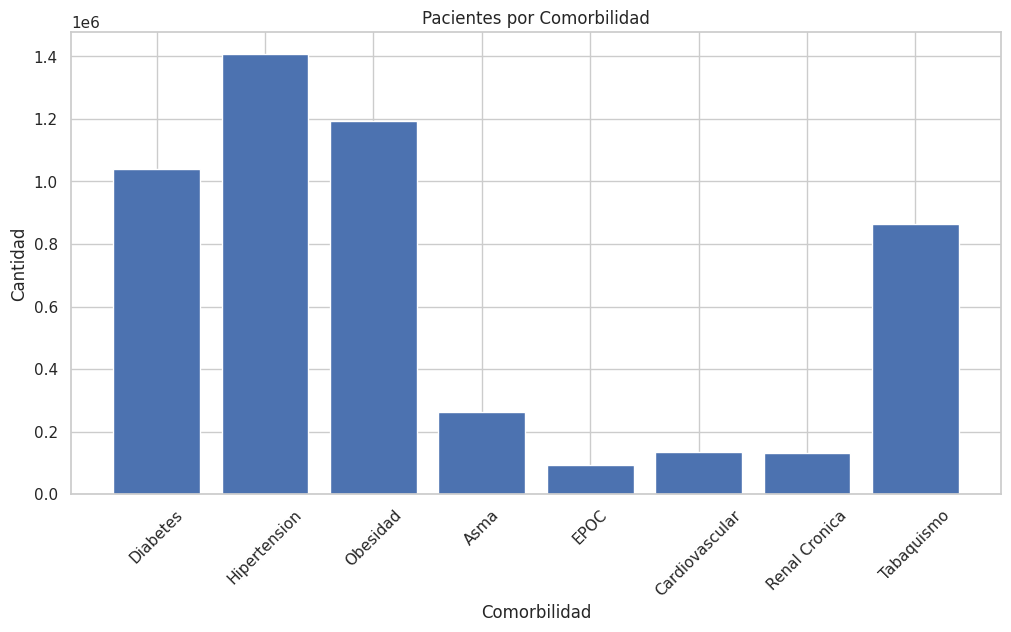

In [33]:
comorbilidades = {
    'Diabetes': (df['DIABETES'] == 'Si').sum(),
    'Hipertension': (df['HIPERTENSION'] == 'Si').sum(),
    'Obesidad': (df['OBESIDAD'] == 'Si').sum(),
    'Asma': (df['ASMA'] == 'Si').sum(),
    'EPOC': (df['EPOC'] == 'Si').sum(),
    'Cardiovascular': (df['CARDIOVASCULAR'] == 'Si').sum(),
    'Renal Cronica': (df['RENAL_CRONICA'] == 'Si').sum(),
    'Tabaquismo': (df['TABAQUISMO'] == 'Si').sum()
}

print(comorbilidades)

plt.figure(figsize=(12,6))

plt.bar(
    comorbilidades.keys(),
    comorbilidades.values()
)

plt.title('Pacientes por Comorbilidad')
plt.xlabel('Comorbilidad')
plt.ylabel('Cantidad')

plt.xticks(rotation=45)

plt.show()

###Probabilidades por Comorbilidad e Interpretación Estadística

In [34]:
total = len(df)

diabetes = (df['DIABETES'] == 'Si').sum()

probabilidad = diabetes / total

print('Total de pacientes:', total)

print('Pacientes con diabetes:', diabetes)

print('Probabilidad de diabetes:', probabilidad)

Total de pacientes: 12634194
Pacientes con diabetes: 1038459
Probabilidad de diabetes: 0.08219432122064929


In [35]:
prob_estado = df.groupby('ENTIDAD_NAC')['DIABETES'].apply(
    lambda x: (x == 'Si').mean()
)

print(prob_estado)

ENTIDAD_NAC
99                      0.024336
Aguascalientes          0.075668
Baja California         0.085036
Baja California Sur     0.071792
Campeche                0.087880
Chiapas                 0.082385
Chihuahua               0.105604
Ciudad De México        0.065107
Coahuila De Zaragoza    0.094631
Colima                  0.080198
Durango                 0.091244
Guanajuato              0.092692
Guerrero                0.105741
Hidalgo                 0.119189
Jalisco                 0.108233
Michoacán De Ocampo     0.090339
Morelos                 0.072710
México                  0.066809
Nayarit                 0.095501
Nuevo León              0.091837
Oaxaca                  0.098635
Puebla                  0.107409
Querétaro               0.083779
Quintana Roo            0.045162
San Luis Potosí         0.096841
Sinaloa                 0.100987
Sonora                  0.095567
Tabasco                 0.090377
Tamaulipas              0.110388
Tlaxcala                0.09757

##Ejercicio de Distribucion Normal

In [37]:
media = 2360

sigma = 714

probabilidad = norm.cdf(3000, media, sigma) - norm.cdf(2000, media, sigma)

print('Respuesta: La probabilidad seria:', probabilidad)

Respuesta: La probabilidad seria: 0.5079095196676364


# Interpretación General

#####En este proyecto se realizó un análisis estadístico de datos sobre COVID-19 utilizando Python, aplicando herramientas como pandas para el manejo de la base de datos y librerías de visualización como matplotlib o seaborn. A partir del tratamiento de una gran cantidad de registros, se logró obtener una visión general del comportamiento de los casos, identificando tendencias importantes como la distribución de pacientes por estado, edad, tipo de paciente y comorbilidades.
#####Además, mediante el uso de estadísticas descriptivas y probabilidades, se analizaron aspectos clave como la proporción de casos positivos, hospitalizados y con distintas enfermedades previas. Las gráficas permitieron representar de forma clara la evolución y distribución de los datos, facilitando la interpretación de patrones que no serían fáciles de observar solo con números. También se trabajó con un modelo de distribución normal para estimar probabilidades, lo que ayudó a reforzar el enfoque estadístico del análisis.
#####En general, consideramos que el proyecto permite comprender cómo la estadística y la programación se complementan para el análisis de datos reales y de gran escala, como los relacionados con la pandemia.


# Conclusiones
####Juan Antonio Alvarado Barron
#####Como equipo, concluimos que el uso de Python facilita enormemente el análisis de grandes volúmenes de datos, ya que permite organizar, procesar y visualizar la información de manera más eficiente y comprensible. Además, aprendimos que la estadística no solo es teoría, sino una herramienta práctica para interpretar situaciones reales como la evolución del COVID-19 que fue este ultimo caso.


####Angel Rios
#####Se pudo llegar a la conclusion que las visualizaciones y el análisis de probabilidades son fundamentales para entender mejor los datos, ya que ayudan a identificar patrones, relaciones y comportamientos que no son tan obvios a simple vista. Este proyecto nos permitió reforzar nuestros conocimientos en estadística y mejorar nuestras habilidades en programación, sobretodo en el lenguaje de Python.
